# Noisy kXOR: Block-encoding the Kikuchi Matrix

Section 4.4.2 Simulating the Kikuchi Hamiltonian

This module contains oracles to implement the block-encoding of the Kikuchi
Hamiltonian corresponding to an input k-XOR-SAT instance.

References:
    [Quartic quantum speedups for planted inference](https://arxiv.org/abs/2406.19378v1)
    Section 4.4.2 for algorithm. Section 2.4 for definitions and notation.

In [ ]:
from qualtran import Bloq, CompositeBloq, BloqBuilder, Signature, Register
from qualtran import QBit, QInt, QUInt, QAny
from qualtran.drawing import show_bloq, show_call_graph, show_counts_sigma
from typing import *
import numpy as np
import sympy
import cirq

## `KikuchiMatrixEntry`
Adjacency matrix oracle for the Kikuchi matrix.

Given a kXOR instance $\mathcal{I}$ with $n$ variables, $m$ constraints,
the Kikuchi matrix with parameter $\ell$ is indexed by ${[n] \choose l}$.
For $S, T \in {[n] \choose l}$, the entry is given by
$H_{S, T} = B_{\mathcal{I}}(S \Delta T)/M$, where $M$ is the max entry.

This bloq implements the transform:
    $$
    |0 \rangle |S\rangle |T\rangle
    \mapsto
    (\sqrt{H_{S, T}}|0\rangle + \sqrt{1 - |H_{S, T}|}|1\rangle)|S\rangle |T\rangle
    $$

This is equivalent to $O_H$ (Def. 4.3) from the paper, but is optimized to classically
compute the `arccos` of the entries, and directly apply the rotation,
instead of computing them using a quantum circuit.

This bloq performs the following steps
1. Compute the symmetric difference $D = S \Delta T$.
2. Compute the index $j$ s.t. $U_j = D$ (where $U_j$ are a list of unique scopes)
4. Apply a controlled Y-rotation with angle for the $j$-th entry.
5. Uncompute steps 3, 2, 1.

#### Parameters
 - `inst`: k-XOR instance
 - `ell`: the Kikuchi parameter $\ell$, must be a multiple of $k$.
 - `entry_bitsize`: number of bits to approximate each rotation angle to.
 - `cv`: single bit control value (0 or 1), or None for uncontrolled (default). 

#### Registers
 - `S`: row index
 - `T`: column index
 - `q`: the qubit to rotate by $Ry(2 \arccos(\sqrt{H_{S,T} / M}))$ as defined above. 

#### References
 - [Quartic quantum speedups for planted inference](https://arxiv.org/abs/2406.19378v1). Definition 4.3. Theorem 4.17 para 3.


In [ ]:
from qualtran.bloqs.max_k_xor_sat import KikuchiMatrixEntry

## `KikuchiNonZeroIndex`
Adjacency list oracle $O_F$ for the Kikuchi matrix.

The oracle $O_F$ (Definition 4.5) takes in $i, k$,
and outputs $i, f(i, k)$ where $f(i, k)$ is
index of the $k$-th non-zero entry in row $i$.

As the Kikuchi matrix is symmetric, we can use the same oracle for both rows and columns.

The Kikuchi matrix is indexed by $S \in {[n] \choose k}$.
For a given row $S$ and column $T$, the entry $\mathcal{K}_{k}_{S, T}$
is potentially non-zero if $S \Delta T = U_j$ for some $j$, which is
equivalent to $T = S \Delta U_j$.
Here, $U_j$ is the $j$-th unique scope in the instance $\mathcal{I}$.

To find the $k$-th non-zero entry, we use two oracles:
1. $(S, k) \mapsto f(S, k)$, implemented by `ColumnOfKthNonZeroEntry`
2. $(S, f(S, k)) \mapsto k$, implemented by `IndexOfNonZeroColumn`.

Both these above oracles are unitary: they do not have any entangled ancilla/junk registers.


Note on sparsity: This bloq expects the user to provide the sparsity, as it is in general
difficult to compute the precise sparsity of the Kikuchi matrix efficiently. As long as the
provided number is at least the true sparsity, the algorithm will work as expected.
In case the provides sparsity is smaller, it is equivalent to making the remaining entries zero in the final block encoding.

#### Parameters
 - `inst`: the kXOR instance $\mathcal{I}$.
 - `ell`: Kikuchi parameter $\ell$.
 - `s`: sparsity, i.e. max number of non-zero entries in a row/column. 

#### Registers
 - `i`: integer in [2^N]
 - `k`: integer in [2^N] 

#### References
 - [Quartic quantum speedups for planted inference](https://arxiv.org/abs/2406.19378v1). Theorem 4.17, proof para 4 (top of page 39).


In [ ]:
from qualtran.bloqs.max_k_xor_sat import KikuchiNonZeroIndex

## `KikuchiHamiltonian`
Block encoding of the Kikuchi matrix $\mathcal{K}_\ell$.

This is implemented by a sparse matrix block encoding using the adjacency matrix
and adjacency list oracles.

This assumes a default sparsity of $\bar{m}$, which is the number of unique
scopes in the instance $\mathcal{I}$.
If a better bound on sparsity is known, it can be passed in by the user.

#### Parameters
 - `inst`: kXOR instance $\mathcal{I}$.
 - `ell`: Kikuchi parameter $\ell$.
 - `entry_bitsize`: Number of bits $b$ to approximate the matrix entries (angles) to.
 - `s`: sparsity of the Kikuchi matrix, defaults to $\bar{m}$.


In [ ]:
from qualtran.bloqs.max_k_xor_sat import KikuchiHamiltonian

### Example Instances

In [ ]:
from qualtran.bloqs.max_k_xor_sat.kxor_instance import KXorInstance

n, m, k, c = sympy.symbols("n m k c", positive=True, integer=True)
inst = KXorInstance.symbolic(n=n, m=m, k=k)
ell = c * k

kikuchi_matrix_symb = KikuchiHamiltonian(inst, ell)

In [ ]:
from qualtran.bloqs.max_k_xor_sat.kxor_instance import example_kxor_instance

inst = example_kxor_instance()
ell = 8

kikuchi_matrix = KikuchiHamiltonian(inst, ell)

#### Graphical Signature

In [ ]:
from qualtran.drawing import show_bloqs
show_bloqs([kikuchi_matrix_symb, kikuchi_matrix],
           ['`kikuchi_matrix_symb`', '`kikuchi_matrix`'])

### Call Graph

In [ ]:
from qualtran.resource_counting.generalizers import ignore_split_join
kikuchi_matrix_symb_g, kikuchi_matrix_symb_sigma = kikuchi_matrix_symb.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(kikuchi_matrix_symb_g)
show_counts_sigma(kikuchi_matrix_symb_sigma)

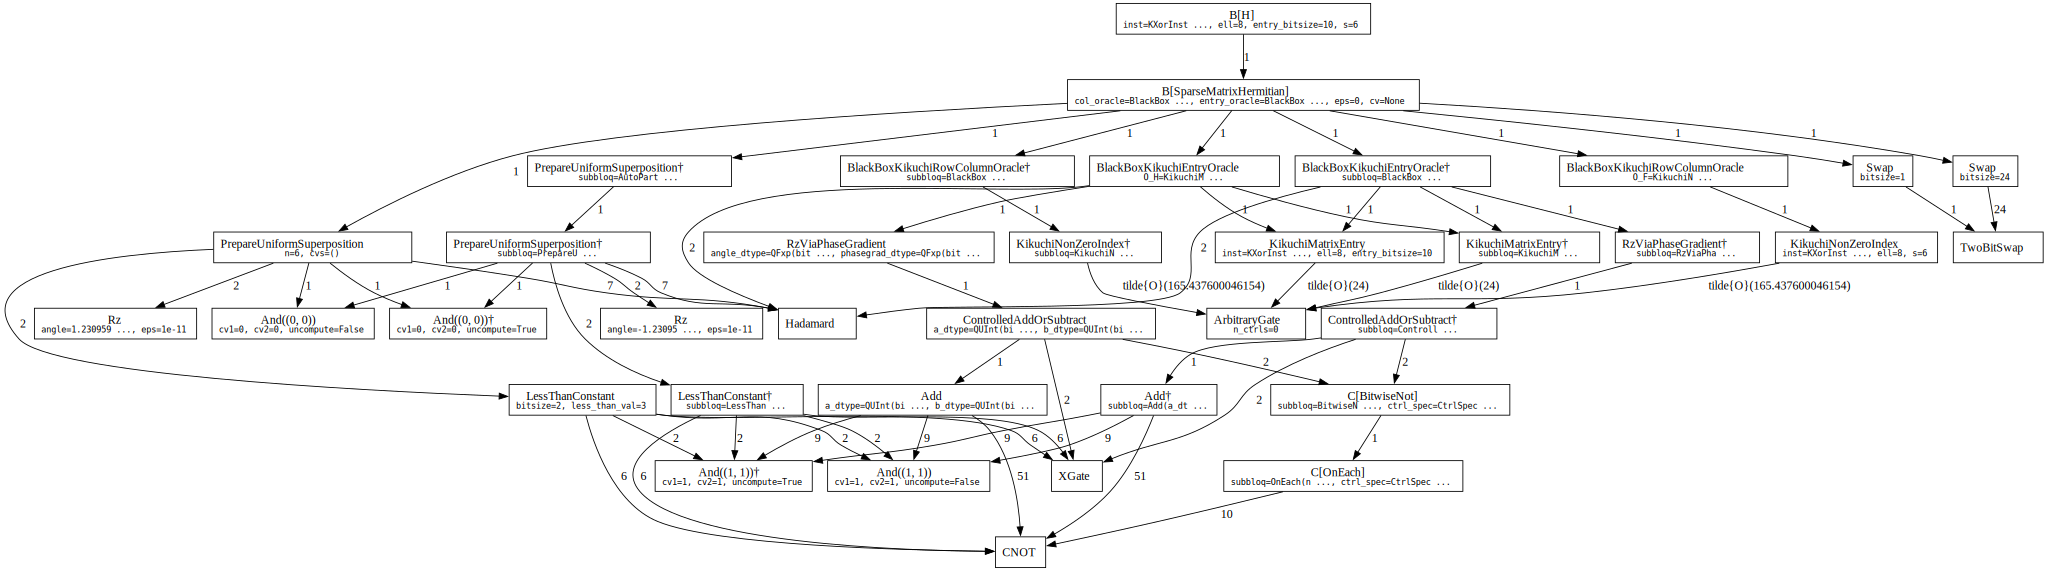

#### Counts totals:
 - `And((0, 0))`: 2
 - `And((0, 0))†`: 2
 - `And((1, 1))`: 26
 - `And((1, 1))†`: 26
 - `ArbitraryGate`: $\displaystyle 4 \tilde{O}{\left(24 \right)} + 2 \tilde{O}{\left(165.437600046154 \right)}$
 - `CNOT`: 166
 - `H`: 18
 - `Rz(-0.3918265520306073π)`: 2
 - `Rz(0.3918265520306073π)`: 2
 - `TwoBitSwap`: 25
 - `XGate`: 28

In [18]:
from qualtran.resource_counting.generalizers import ignore_alloc_free
g, sigma = kikuchi_matrix.call_graph(generalizer=[ignore_split_join, ignore_alloc_free])
show_call_graph(g)
show_counts_sigma(sigma)

### Example Instances

In [ ]:
from qualtran.bloqs.max_k_xor_sat.kxor_instance import KXorInstance

n, m, k, c = sympy.symbols("n m k c", positive=True, integer=True)
inst = KXorInstance.symbolic(n=n, m=m, k=k)
ell = c * k

kikuchi_matrix_entry_symb = KikuchiMatrixEntry(inst, ell, entry_bitsize=3)

In [ ]:
from qualtran.bloqs.max_k_xor_sat.kxor_instance import example_kxor_instance

inst = example_kxor_instance()
ell = 8

kikuchi_matrix_entry = KikuchiMatrixEntry(inst, ell, entry_bitsize=3)

#### Graphical Signature

In [ ]:
from qualtran.drawing import show_bloqs
show_bloqs([kikuchi_matrix_entry_symb, kikuchi_matrix_entry],
           ['`kikuchi_matrix_entry_symb`', '`kikuchi_matrix_entry`'])

### Call Graph

In [ ]:
from qualtran.resource_counting.generalizers import ignore_split_join
kikuchi_matrix_entry_symb_g, kikuchi_matrix_entry_symb_sigma = kikuchi_matrix_entry_symb.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(kikuchi_matrix_entry_symb_g)
show_counts_sigma(kikuchi_matrix_entry_symb_sigma)

### Example Instances

In [ ]:
from qualtran.bloqs.max_k_xor_sat.kxor_instance import KXorInstance

n, m, k, c, s = sympy.symbols("n m k c s", positive=True, integer=True)
inst = KXorInstance.symbolic(n=n, m=m, k=k)
ell = c * k

kikuchi_nonzero_index_symb = KikuchiNonZeroIndex(inst, ell, s=s)

In [ ]:
from qualtran.bloqs.max_k_xor_sat.kxor_instance import example_kxor_instance

inst = example_kxor_instance()
ell = 8
s = inst.brute_force_sparsity(ell)

kikuchi_nonzero_index = KikuchiNonZeroIndex(inst, ell, s=s)

#### Graphical Signature

In [ ]:
from qualtran.drawing import show_bloqs
show_bloqs([kikuchi_nonzero_index_symb, kikuchi_nonzero_index],
           ['`kikuchi_nonzero_index_symb`', '`kikuchi_nonzero_index`'])

### Call Graph

In [ ]:
from qualtran.resource_counting.generalizers import ignore_split_join
kikuchi_nonzero_index_symb_g, kikuchi_nonzero_index_symb_sigma = kikuchi_nonzero_index_symb.call_graph(max_depth=1, generalizer=ignore_split_join)
show_call_graph(kikuchi_nonzero_index_symb_g)
show_counts_sigma(kikuchi_nonzero_index_symb_sigma)